In [1]:
import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
except ModuleNotFoundError:
    _here = Path().resolve()
    DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)

if DRIVE_ROOT not in sys.path:
    sys.path.insert(0, DRIVE_ROOT)
print(f"DRIVE_ROOT: {DRIVE_ROOT}")

INPUT_JSONL       = f'{DRIVE_ROOT}/data/filtered_pairs.jsonl'
OUTPUT_JSONL      = f'{DRIVE_ROOT}/data/captioned_pairs.jsonl'
PREBUILT_CAPTIONS = f'{DRIVE_ROOT}/data/prebuilt_captions.json'


Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive/liya_diploma


In [2]:
import json
from pathlib import Path

from scripts.caption_llava import caption_batch

# подхватываем готовые подписи из ноутбука 01, остальные допишет LLaVA
if Path(PREBUILT_CAPTIONS).exists():
    with open(PREBUILT_CAPTIONS, encoding='utf-8') as f:
        prebuilt = json.load(f)
    with open(INPUT_JSONL, encoding='utf-8') as f:
        pairs = [json.loads(l) for l in f]

    already_done = set()
    if Path(OUTPUT_JSONL).exists():
        with open(OUTPUT_JSONL, encoding='utf-8') as f:
            already_done = {json.loads(l)['png_path'] for l in f if l.strip()}

    n_added = 0
    with open(OUTPUT_JSONL, 'a', encoding='utf-8') as out:
        for item in pairs:
            png = item['png_path']
            if png in prebuilt and png not in already_done:
                item['caption'] = prebuilt[png]
                out.write(json.dumps(item, ensure_ascii=False) + '\n')
                n_added += 1
    print(f"Pre-populated {n_added} captions from {PREBUILT_CAPTIONS}")
else:
    print(f"No prebuilt captions at {PREBUILT_CAPTIONS}; LLaVA подпишет всё.")

caption_batch(input_jsonl=INPUT_JSONL, output_jsonl=OUTPUT_JSONL)
print("Captioning complete")


Pre-populated 0 captions from /content/drive/MyDrive/liya_diploma/data/prebuilt_captions.json
Captioning 0 images (10000 already done)
Nothing to do — all images already captioned.
Captioning complete


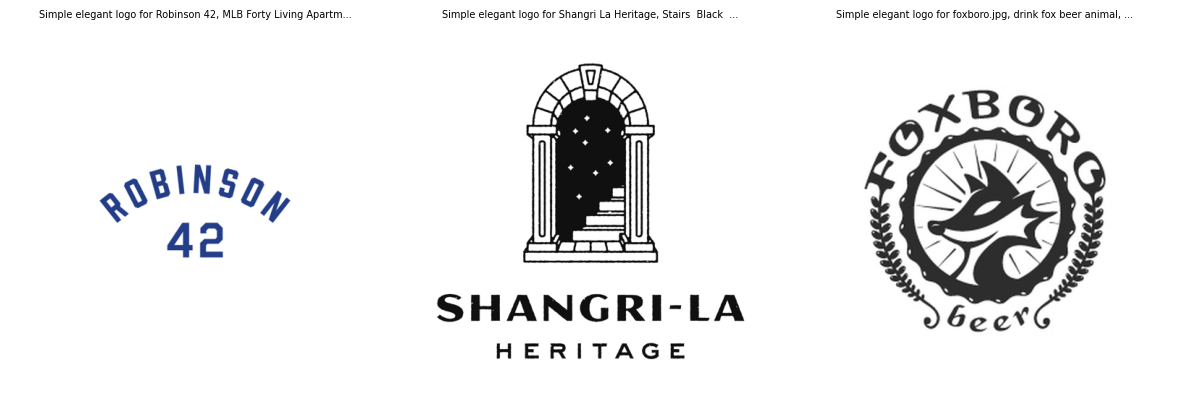

Total captioned: 10000


In [3]:
import json
import random

import matplotlib.pyplot as plt
from PIL import Image

with open(OUTPUT_JSONL) as f:
    captioned = [json.loads(l) for l in f]

if not captioned:
    print("No captions found - смотри вывод предыдущей ячейки на ошибки.")
else:
    sample = random.sample(captioned, min(3, len(captioned)))
    fig, axes = plt.subplots(1, len(sample), figsize=(12, 4), squeeze=False)
    for ax, item in zip(axes[0], sample):
        ax.imshow(Image.open(item['png_path']))
        ax.set_title(item['caption'][:60] + "...", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{DRIVE_ROOT}/results/experiments/caption_sample.png', dpi=150)
    plt.show()
    print(f"Total captioned: {len(captioned)}")
